# 03 — Context and Comparison

> **"A number without context is just a number. A number with a benchmark is an insight."**

---

Dữ liệu không có ý nghĩa tuyệt đối — ý nghĩa đến từ **so sánh**.

- 6% tăng trưởng là tốt hay xấu? → Cần biết target, industry average, hay historical baseline.
- Revenue $10M là cao hay thấp? → Cần so sánh với cùng kỳ năm trước, với đối thủ, với kế hoạch.

**Context Injection** là kỹ thuật nhúng điểm tham chiếu trực tiếp vào chart để số liệu tự nói lên ý nghĩa của nó.

### Nội dung notebook này:

1. **Reference Lines** — Mean, median, và custom threshold
2. **Target Lines & Zones** — So sánh actual vs goal
3. **Benchmark Bands** — Industry range / acceptable zone
4. **Excess & Deficit** — Tô màu phần vượt / thiếu so với baseline
5. **Before vs After** — So sánh hai trạng thái trực tiếp
6. **Relative Performance** — Index về cùng base = 100
7. **Distribution Comparison** — KDE overlaid và ridge plot
8. **Small Multiples** — Faceted comparison grid

## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid, make_grid
from vizint.context import (
    add_reference_line,
    add_mean_line,
    add_median_line,
    add_benchmark_band,
    shade_above_benchmark,
    shade_below_benchmark,
    add_target_line,
    add_target_zone,
    shade_excess,
    shade_deficit,
)
from vizint.comparison import (
    compare_lines,
    before_after_lines,
    compare_distributions,
    ridge_plot,
    relative_performance_chart,
    small_multiples,
)
from vizint.annotation import label_last_point, add_note, add_caption
from vizint.core.axes_utils import format_thousands, format_percent

np.random.seed(2024)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Tạo 3 tập dữ liệu:
1. **Monthly revenue** — 1 công ty, 36 tháng, với target và benchmark
2. **Stock prices** — 5 công ty, 60 tháng, để so sánh relative performance
3. **Score distributions** — 4 nhóm, để so sánh distribution

In [2]:
# --- Dataset 1: Monthly Revenue ---
T = 36
months = np.arange(T)

revenue = (
    800
    + np.linspace(0, 200, T)          # uptrend
    + 40 * np.sin(2 * np.pi * months / 12)  # seasonality
    + np.random.randn(T) * 25          # noise
)

TARGET    = 950     # monthly revenue target
BENCHMARK_LOW  = 820
BENCHMARK_HIGH = 920

month_labels = [
    f"{'JFMAMJJASOND'[i % 12]}" for i in range(T)
]

# --- Dataset 2: Stock Prices (5 companies, 60 months) ---
T2 = 60
t2 = np.arange(T2)
stocks = {
    'Alpha':   100 + np.cumsum(np.random.randn(T2) * 1.8 + 0.4),
    'Beta':    100 + np.cumsum(np.random.randn(T2) * 2.1 + 0.2),
    'Gamma':   100 + np.cumsum(np.random.randn(T2) * 1.5 + 0.6),
    'Delta':   100 + np.cumsum(np.random.randn(T2) * 2.5 - 0.1),
    'Epsilon': 100 + np.cumsum(np.random.randn(T2) * 1.2 + 0.3),
}

# --- Dataset 3: Score distributions (4 groups) ---
score_groups = {
    'Group A (Control)':  np.random.normal(72, 8,  200),
    'Group B (Treatment 1)': np.random.normal(78, 7,  200),
    'Group C (Treatment 2)': np.random.normal(82, 10, 200),
    'Group D (Elite)':    np.random.normal(88, 6,  200),
}

print(f'Revenue range : [{revenue.min():.0f}, {revenue.max():.0f}]')
print(f'Stocks        : {list(stocks.keys())}')
print(f'Score groups  : {list(score_groups.keys())}')

Revenue range : [769, 1002]
Stocks        : ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon']
Score groups  : ['Group A (Control)', 'Group B (Treatment 1)', 'Group C (Treatment 2)', 'Group D (Elite)']


---
## 1. Reference Lines — Mean, Median, Custom

**Reference line** là đường ngang/dọc đánh dấu một ngưỡng tham chiếu.
Nó trả lời câu hỏi: *"So với mức này, data đang ở đâu?"*

- `add_mean_line` / `add_median_line` — tự tính từ data và vẽ
- `add_reference_line` — custom value, horizontal hoặc vertical

**Mean vs Median:**
- **Mean** phù hợp khi distribution gần symmetric
- **Median** phù hợp hơn khi có outlier (median robust hơn)

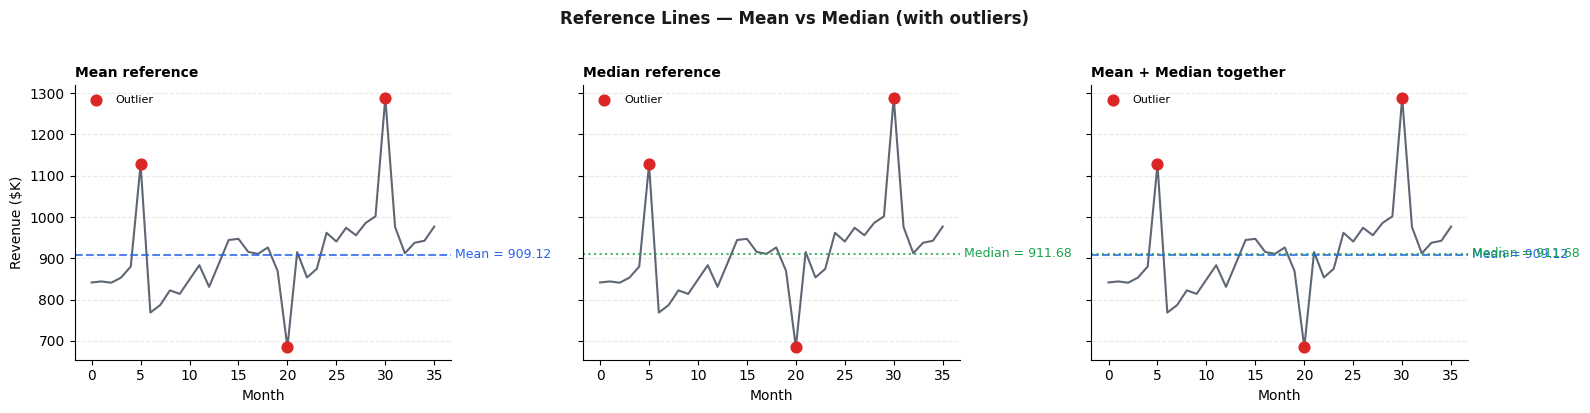

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white', sharey=True)

# Tạo series có outlier để thấy rõ mean vs median
revenue_with_spike = revenue.copy()
revenue_with_spike[[5, 20, 30]] += np.array([250, -200, 300])  # inject outliers

titles = ['Mean reference', 'Median reference', 'Mean + Median together']

for i, (ax, title) in enumerate(zip(axes, titles)):
    ax.plot(months, revenue_with_spike, color='#374151', linewidth=1.5, alpha=0.8)
    ax.scatter([5, 20, 30], revenue_with_spike[[5, 20, 30]],
               color='#DC2626', s=60, zorder=5, label='Outlier')

    if i == 0 or i == 2:
        add_mean_line(ax, revenue_with_spike, color='#2563EB',
                      linewidth=1.5, show_label=True)
    if i == 1 or i == 2:
        add_median_line(ax, revenue_with_spike, color='#16A34A',
                        linewidth=1.5, show_label=True)

    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    ax.set_xlabel('Month')
    if i == 0:
        ax.set_ylabel('Revenue ($K)')
    ax.legend(frameon=False, fontsize=8)
    despine(ax); set_grid(ax)

fig.suptitle('Reference Lines — Mean vs Median (with outliers)',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

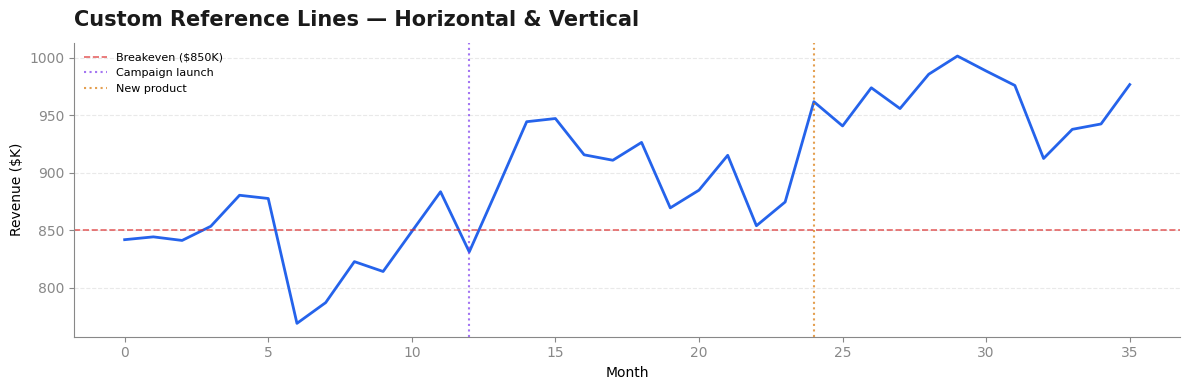

In [4]:
# Custom reference lines — vertical + horizontal kết hợp
chart = (
    ChartBuilder(figsize=(12, 4))
    .set_title('Custom Reference Lines — Horizontal & Vertical')
    .build()
)
ax = chart.ax

ax.plot(months, revenue, color='#2563EB', linewidth=2.0)

# Horizontal: breakeven threshold
add_reference_line(ax, value=850, orientation='h',
                   color='#DC2626', linestyle='--', linewidth=1.2,
                   label='Breakeven ($850K)')

# Vertical: campaign launch at month 12
add_reference_line(ax, value=12, orientation='v',
                   color='#7C3AED', linestyle=':', linewidth=1.5,
                   label='Campaign launch')

# Vertical: new product at month 24
add_reference_line(ax, value=24, orientation='v',
                   color='#D97706', linestyle=':', linewidth=1.5,
                   label='New product')

ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. Target Lines & Target Zones

**Target line** — một ngưỡng cứng phải đạt được (KPI target, quota).

**Target zone** — một khoảng chấp nhận được (acceptable range).
Phù hợp khi mục tiêu không phải một con số tuyệt đối mà là một khoảng:
- Inflation target: 2–4%
- Blood pressure: 80–120 mmHg
- Inventory level: 500–1500 units

Kết hợp target line + fill_between để hiển thị rõ **khi nào đạt, khi nào không đạt**.

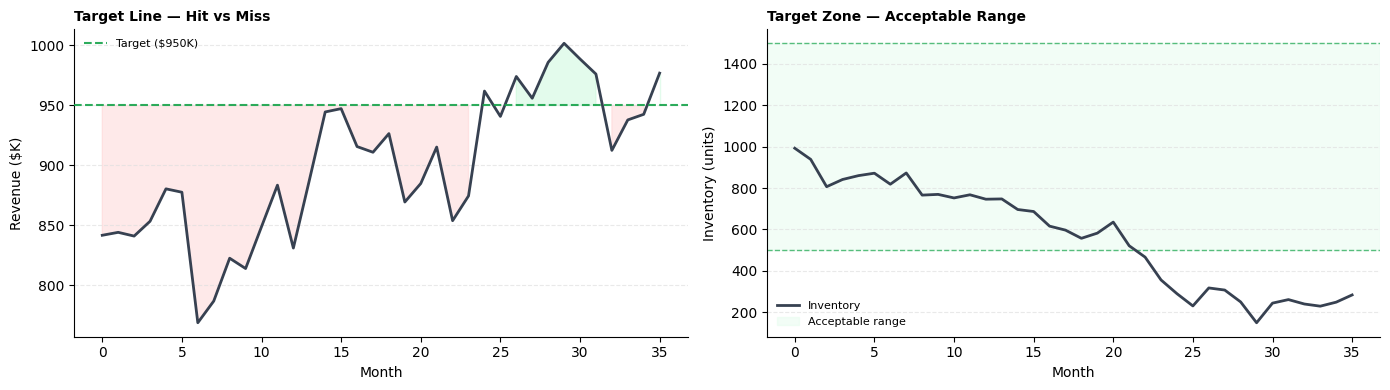

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: Target line + above/below shading
ax = axes[0]
ax.plot(months, revenue, color='#374151', linewidth=2.0)
add_target_line(ax, TARGET, color='#16A34A', linewidth=1.5,
                linestyle='--', label=f'Target (${TARGET}K)')

# Shade above (met target) and below (missed target)
shade_above_benchmark(ax, months, revenue, TARGET,
                      color='#BBF7D0', alpha=0.4)
shade_below_benchmark(ax, months, revenue, TARGET,
                      color='#FECACA', alpha=0.4)

ax.set_title('Target Line — Hit vs Miss', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 2: Target zone
ax = axes[1]

# Simulate inventory level
inventory = 1000 + np.cumsum(np.random.randn(T) * 60)
ax.plot(months, inventory, color='#374151', linewidth=2.0, label='Inventory')
add_target_zone(ax, lower=500, upper=1500,
                color='#DCFCE7', alpha=0.35,
                border_color='#16A34A', border_style='--',
                label='Acceptable range')

ax.set_title('Target Zone — Acceptable Range', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Inventory (units)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 3. Benchmark Bands

**Benchmark band** = vùng tô màu đại diện cho **industry average range** hoặc **historical normal range**.

Khác với target zone:
- **Target zone** — do bạn đặt ra (internal goal)
- **Benchmark band** — đến từ bên ngoài (industry, market, peer group)

Khi actual nằm ngoài benchmark band → tín hiệu đáng chú ý (tốt hoặc xấu).

C:\Users\Duy\AppData\Local\Temp\ipykernel_25276\2042046825.py:36: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\Duy\AppData\Local\Temp\ipykernel_25276\2042046825.py:36: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


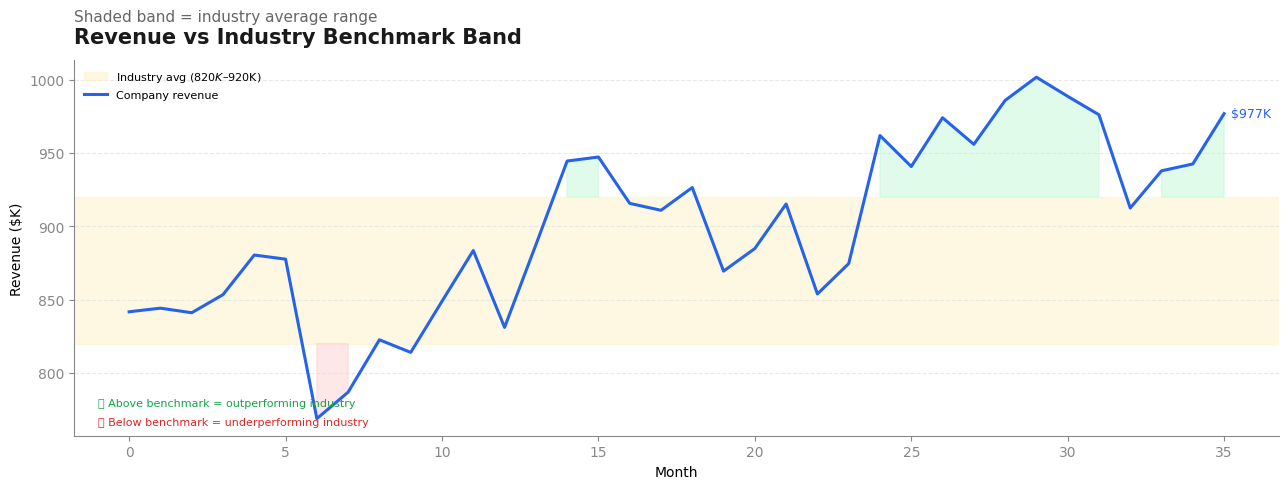

In [6]:
chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('Revenue vs Industry Benchmark Band')
    .set_subtitle('Shaded band = industry average range')
    .build()
)
ax = chart.ax

# Benchmark band (industry range)
add_benchmark_band(ax, lower=BENCHMARK_LOW, upper=BENCHMARK_HIGH,
                   color='#FEF3C7', alpha=0.5,
                   label=f'Industry avg (${BENCHMARK_LOW}K–${BENCHMARK_HIGH}K)')

# Actual series
ax.plot(months, revenue, color='#2563EB', linewidth=2.2, label='Company revenue', zorder=3)

# Shade khi vượt benchmark (outperformance)
shade_above_benchmark(ax, months, revenue, BENCHMARK_HIGH,
                      color='#BBF7D0', alpha=0.45)
# Shade khi dưới benchmark (underperformance)
shade_below_benchmark(ax, months, revenue, BENCHMARK_LOW,
                      color='#FECACA', alpha=0.45)

# Label điểm cuối
label_last_point(ax, months, revenue,
                 text=f'${revenue[-1]:.0f}K', color='#2563EB')

add_note(ax, '🟢 Above benchmark = outperforming industry',
         x=0.02, y=0.10, color='#16A34A', fontsize=8)
add_note(ax, '🔴 Below benchmark = underperforming industry',
         x=0.02, y=0.05, color='#DC2626', fontsize=8)

ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## 4. Excess & Deficit Shading

**Excess** = phần vượt trội so với baseline → tô màu xanh lá.

**Deficit** = phần thiếu hụt so với baseline → tô màu đỏ.

Baseline có thể là:
- Một số vô hướng (scalar): target, zero, historical mean
- Một array: previous year, budget line, peer average

Kỹ thuật này đặc biệt hiệu quả cho **P&L charts**, **variance analysis**, và **vs prior year** comparisons.

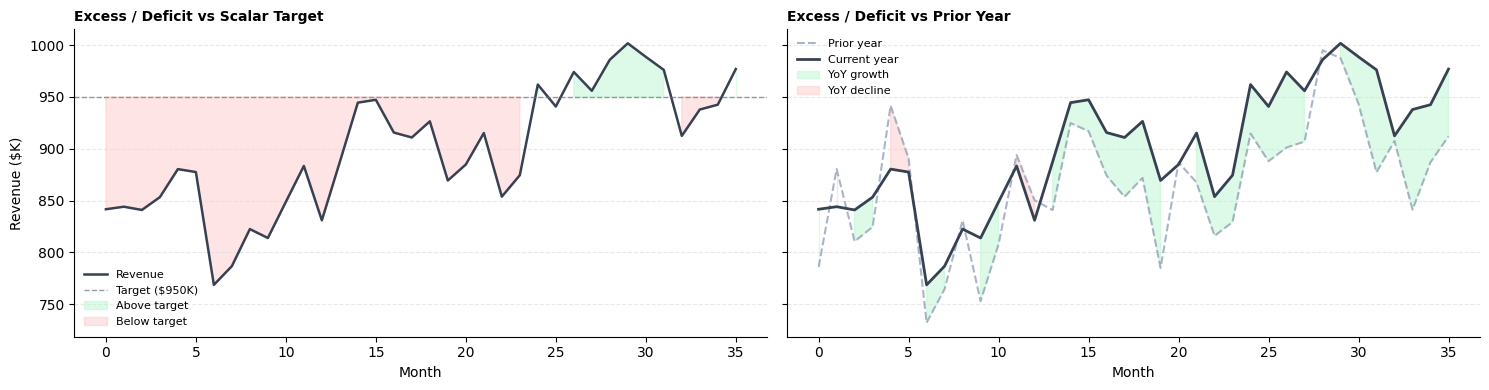

In [7]:
# Prior year revenue (baseline)
prior_year = revenue - np.random.randn(T) * 30 - np.linspace(0, 60, T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), facecolor='white', sharey=True)

# Panel 1: Excess/deficit vs scalar target
ax = axes[0]
ax.plot(months, revenue, color='#374151', linewidth=1.8, label='Revenue')
ax.axhline(TARGET, color='#6B7280', linewidth=1.0, linestyle='--', alpha=0.7,
           label=f'Target (${TARGET}K)')
shade_excess(ax, months, revenue, baseline=TARGET,
             color='#BBF7D0', alpha=0.5, label='Above target')
shade_deficit(ax, months, revenue, baseline=TARGET,
              color='#FECACA', alpha=0.5, label='Below target')
ax.set_title('Excess / Deficit vs Scalar Target', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 2: Excess/deficit vs prior year (array baseline)
ax = axes[1]
ax.plot(months, prior_year, color='#94A3B8', linewidth=1.5,
        linestyle='--', label='Prior year', alpha=0.8)
ax.plot(months, revenue, color='#374151', linewidth=2.0, label='Current year')
shade_excess(ax, months, revenue, baseline=prior_year,
             color='#BBF7D0', alpha=0.5, label='YoY growth')
shade_deficit(ax, months, revenue, baseline=prior_year,
              color='#FECACA', alpha=0.5, label='YoY decline')
ax.set_title('Excess / Deficit vs Prior Year', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 5. Before vs After Comparison

**Before/after** là dạng comparison đơn giản nhất và thường hiệu quả nhất:
overlay hai series lên cùng một chart với fill giữa chúng.

`before_after_lines` tự động:
- Vẽ before (dashed, muted) và after (solid, vivid)
- Fill between — xanh khi after > before, đỏ khi after < before

**Khi nào dùng:** A/B test, policy change, treatment effect, seasonal comparison.

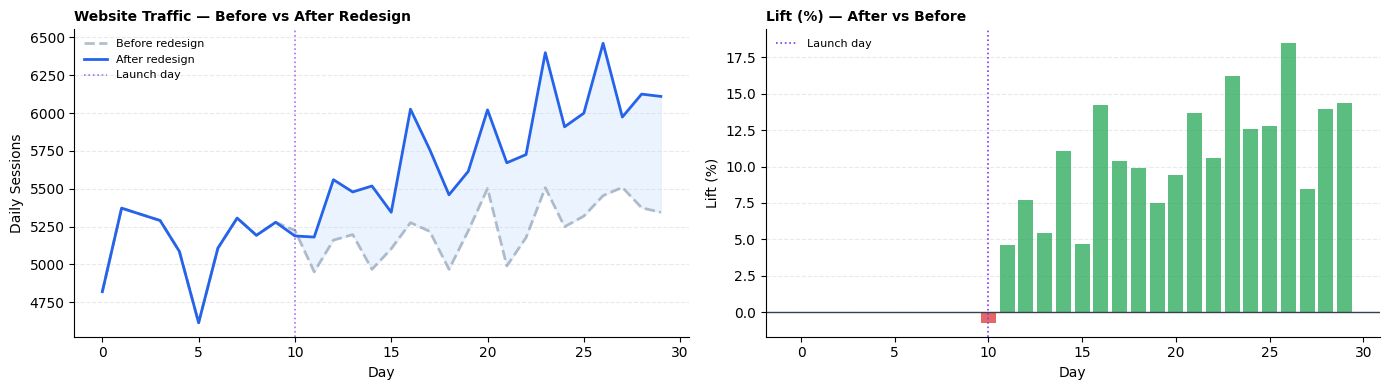

In [8]:
# Simulate: website traffic before and after redesign
T3 = 30
t3 = np.arange(T3)

traffic_before = 5000 + np.random.randn(T3) * 200 + t3 * 10
traffic_after  = traffic_before + np.where(t3 < 10, 0,
                     np.linspace(0, 800, T3)[t3] + np.random.randn(T3) * 150)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: before_after_lines với fill
ax = axes[0]
before_after_lines(
    ax, t3,
    y_before=traffic_before,
    y_after=traffic_after,
    before_color='#94A3B8',
    after_color='#2563EB',
    before_label='Before redesign',
    after_label='After redesign',
    fill=True,
    fill_color='#BFDBFE',
    fill_alpha=0.3,
)
add_reference_line(ax, value=10, orientation='v',
                   color='#7C3AED', linestyle=':', label='Launch day')
ax.set_title('Website Traffic — Before vs After Redesign', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Day'); ax.set_ylabel('Daily Sessions')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 2: lift calculation
ax = axes[1]
lift = (traffic_after - traffic_before) / traffic_before * 100
colors = ['#16A34A' if v >= 0 else '#DC2626' for v in lift]
ax.bar(t3, lift, color=colors, width=0.8, alpha=0.7)
ax.axhline(0, color='#374151', linewidth=1.0)
ax.axvline(10, color='#7C3AED', linewidth=1.2, linestyle=':', label='Launch day')
ax.set_title('Lift (%) — After vs Before', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Day'); ax.set_ylabel('Lift (%)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 6. Relative Performance — Index to Base 100

**Vấn đề với absolute price comparison:**
Nếu Stock A bắt đầu ở $200 và Stock B ở $50, không thể so sánh trực tiếp ai tăng nhiều hơn.

**Giải pháp:** Rebase tất cả về 100 tại điểm gốc.
Sau đó giá trị 120 = tăng 20%, 80 = giảm 20% — bất kể giá gốc.

`index_to_base` rebase một array. `relative_performance_chart` plot nhiều series đã rebase.

C:\Users\Duy\AppData\Local\Temp\ipykernel_25276\1335508690.py:46: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


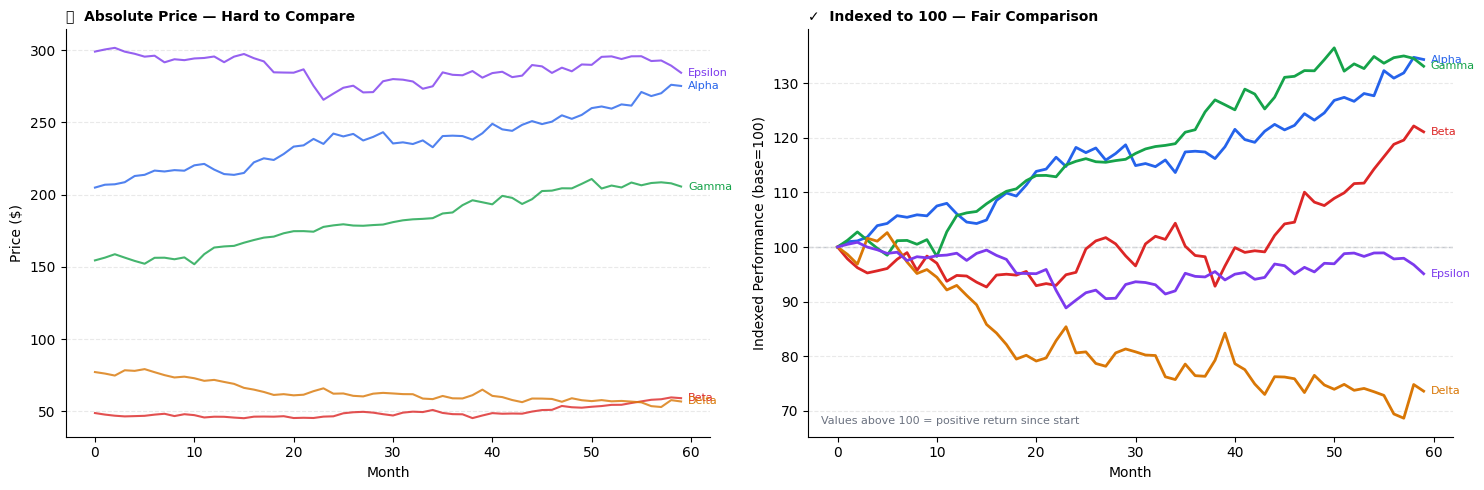

In [9]:
from vizint.comparison.relative import index_to_base

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Absolute prices — hard to compare
ax = axes[0]
abs_prices = {
    'Alpha':   stocks['Alpha'] * 2.0,     # starts at ~$200
    'Beta':    stocks['Beta'] * 0.5,      # starts at ~$50
    'Gamma':   stocks['Gamma'] * 1.5,
    'Delta':   stocks['Delta'] * 0.8,
    'Epsilon': stocks['Epsilon'] * 3.0,
}

colors_stock = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']
for (name, y), c in zip(abs_prices.items(), colors_stock):
    ax.plot(t2, y, color=c, linewidth=1.5, label=name, alpha=0.8)
    label_last_point(ax, t2, y, text=name, color=c, fontsize=8)

ax.set_title('❌  Absolute Price — Hard to Compare', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Price ($)')
despine(ax); set_grid(ax)

# Panel 2: Indexed to 100
ax = axes[1]
relative_performance_chart(
    ax, t2, stocks,
    base_index=0,
    scale=100,
    palette='default',
    linewidth=2.0,
    legend=False,
    reference_line=True,
    reference_color='#9CA3AF',
)
for (name, y), c in zip(stocks.items(), colors_stock):
    indexed = index_to_base(np.asarray(y, float), 0, 100)
    label_last_point(ax, t2, indexed, text=name, color=c, fontsize=8)

ax.set_title('✓  Indexed to 100 — Fair Comparison', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Indexed Performance (base=100)')
add_note(ax, 'Values above 100 = positive return since start',
         x=0.02, y=0.05, fontsize=8, color='#6B7280')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 7. Distribution Comparison

Khi so sánh các nhóm, bar chart chỉ cho thấy mean — ẩn đi phần còn lại của distribution.

**KDE overlay** cho thấy toàn bộ hình dạng phân phối:
- Nhóm nào có spread rộng hơn?
- Có bimodal distribution không?
- Overlap giữa các nhóm là bao nhiêu?

**Ridge plot** (joy plot) phù hợp khi có nhiều nhóm — tránh overlap bằng cách stack dọc.

C:\Users\Duy\AppData\Local\Temp\ipykernel_25276\3646602604.py:30: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


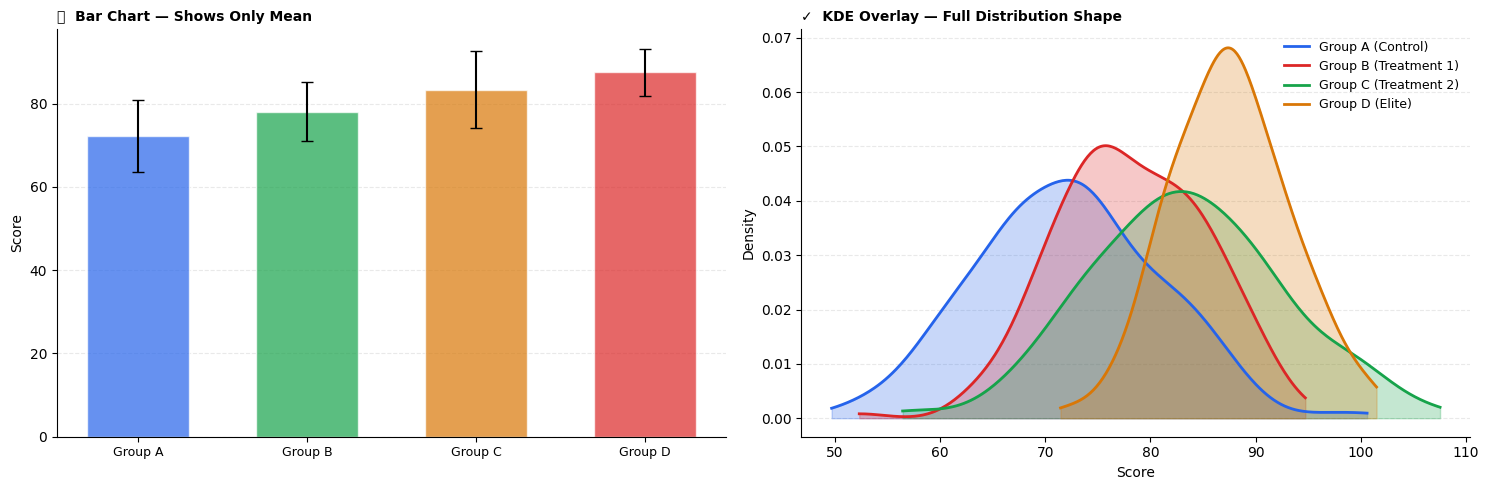

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Bar chart — hides distribution shape
ax = axes[0]
means  = [v.mean() for v in score_groups.values()]
stds   = [v.std()  for v in score_groups.values()]
colors_g = ['#2563EB', '#16A34A', '#D97706', '#DC2626']
ax.bar(range(4), means, color=colors_g, alpha=0.7, width=0.6,
       yerr=stds, capsize=4, edgecolor='white')
ax.set_xticks(range(4))
ax.set_xticklabels(['Group A', 'Group B', 'Group C', 'Group D'], fontsize=9)
ax.set_title('❌  Bar Chart — Shows Only Mean', loc='left', fontsize=10, fontweight='bold')
ax.set_ylabel('Score')
despine(ax); set_grid(ax)

# Panel 2: KDE overlay — shows full distribution
ax = axes[1]
compare_distributions(
    ax, score_groups,
    palette='default',
    alpha=0.25,
    linewidth=2.0,
    legend=True,
)
ax.set_title('✓  KDE Overlay — Full Distribution Shape', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

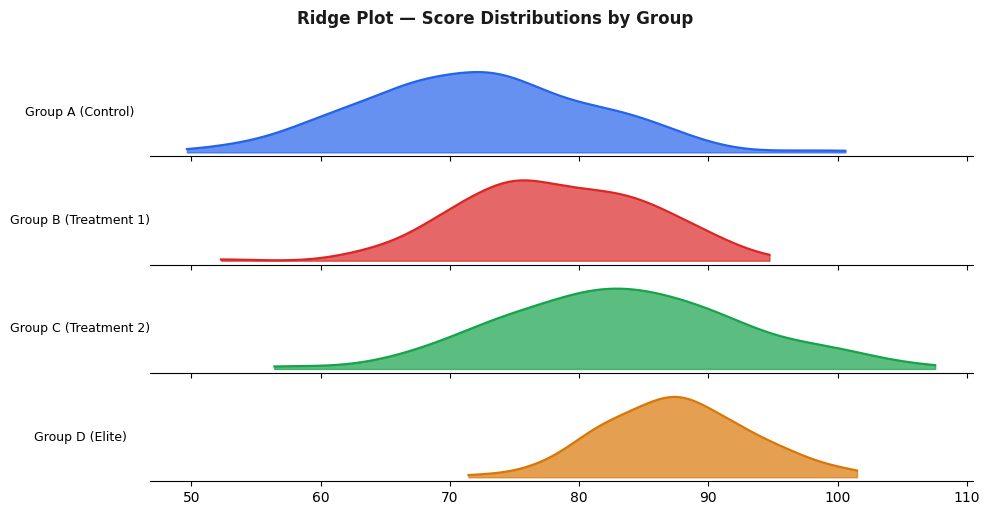

In [11]:
# Ridge plot — tốt cho nhiều nhóm (tránh clutter)
fig = ridge_plot(
    score_groups,
    overlap=0.5,
    palette='default',
    figsize=(10, 5),
)
fig.suptitle('Ridge Plot — Score Distributions by Group',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Small Multiples (Faceted Grid)

**Small multiples** = cùng một chart type, lặp lại cho nhiều nhóm/entities.

Ưu điểm so với overlay:
- Không bị overlap và clutter
- Dễ so sánh pattern hơn (mắt di chuyển theo grid, không theo màu sắc)
- Mỗi panel có thể có y-axis riêng (khi scale khác nhau)

`small_multiples` nhận một dict `{panel_title: (x, y)}` và một `plot_fn(ax, x, y, color)` tùy chỉnh.

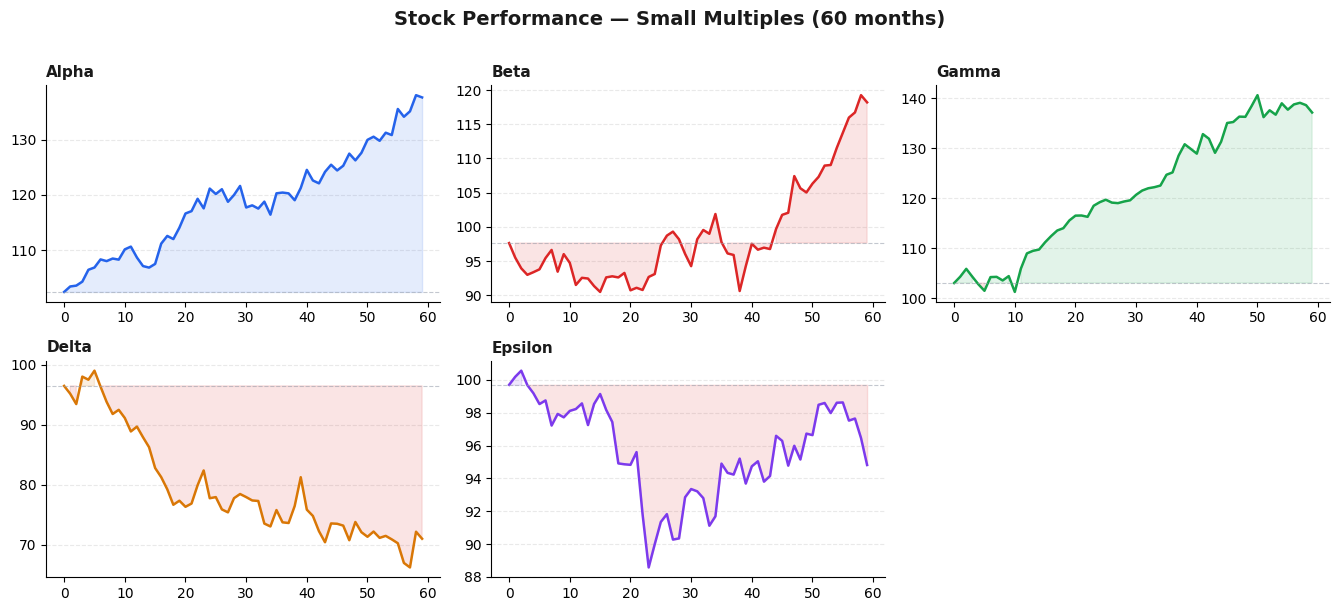

In [12]:
# Prepare panel data: mỗi stock là một panel
panels = {name: (t2, y) for name, y in stocks.items()}

def stock_panel_fn(ax, x, y, color):
    """Custom plot function cho mỗi panel."""
    ax.plot(x, y, color=color, linewidth=1.8)
    ax.axhline(y[0], color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.6)
    # Fill above/below starting price
    ax.fill_between(x, y, y[0],
                    where=(y >= y[0]), color=color, alpha=0.12)
    ax.fill_between(x, y, y[0],
                    where=(y < y[0]), color='#DC2626', alpha=0.12)

fig = small_multiples(
    groups=panels,
    plot_fn=stock_panel_fn,
    ncols=3,
    figsize_per_panel=(4.5, 3.0),
    shared_y=False,
    title_fontsize=11,
    palette='default',
    suptitle='Stock Performance — Small Multiples (60 months)',
    despine_panels=True,
    grid_panels=True,
)
plt.tight_layout()
plt.show()

---
## 9. Putting It All Together — Context Stack

Kết hợp các lớp context trong một chart duy nhất:
benchmark band → target line → excess/deficit → mean reference → event markers.

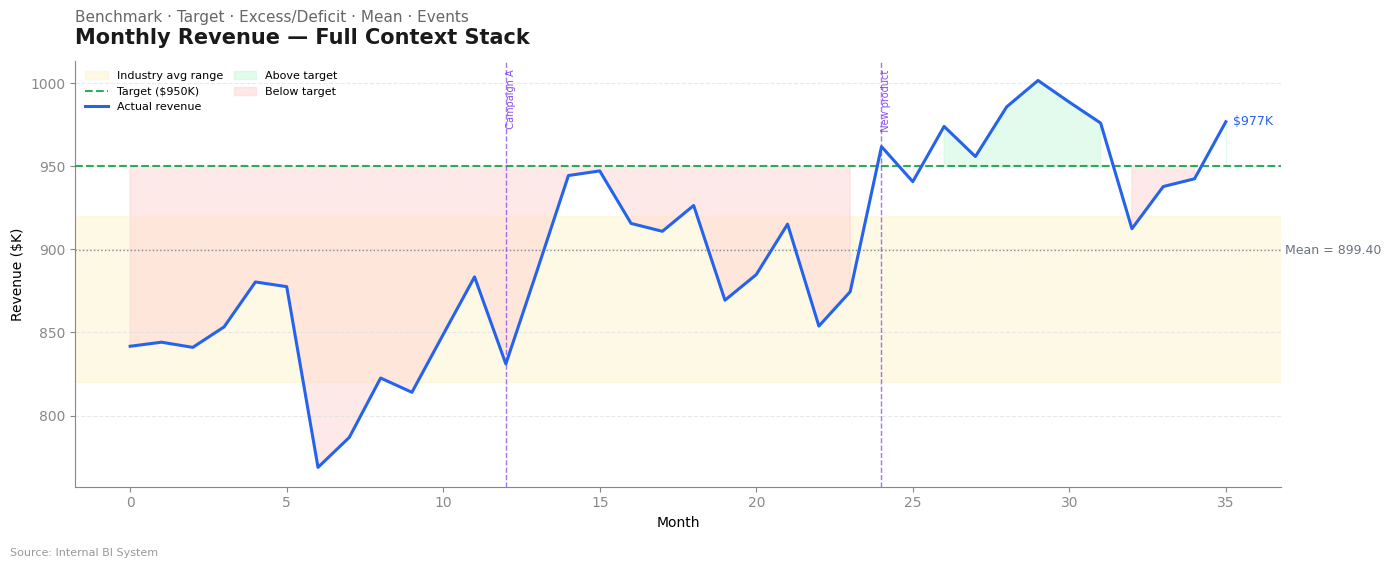

In [13]:
from vizint.narrative import add_event_markers
from vizint.annotation import annotate_with_arrow

chart = (
    ChartBuilder(figsize=(14, 5.5))
    .set_title('Monthly Revenue — Full Context Stack')
    .set_subtitle('Benchmark · Target · Excess/Deficit · Mean · Events')
    .set_source('Internal BI System')
    .build()
)
ax = chart.ax

# Layer 1: Benchmark band (industry range)
add_benchmark_band(ax, BENCHMARK_LOW, BENCHMARK_HIGH,
                   color='#FEF3C7', alpha=0.45,
                   label='Industry avg range')

# Layer 2: Target line
add_target_line(ax, TARGET, color='#16A34A', linewidth=1.5,
                linestyle='--', label=f'Target (${TARGET}K)')

# Layer 3: Actual series
ax.plot(months, revenue, color='#2563EB', linewidth=2.2,
        label='Actual revenue', zorder=4)

# Layer 4: Excess/deficit vs target
shade_excess(ax, months, revenue, baseline=TARGET,
             color='#BBF7D0', alpha=0.4, label='Above target')
shade_deficit(ax, months, revenue, baseline=TARGET,
              color='#FECACA', alpha=0.4, label='Below target')

# Layer 5: Mean reference
add_mean_line(ax, revenue, color='#6B7280', show_label=True,
              linewidth=1.0, linestyle=':')

# Layer 6: Event markers
add_event_markers(ax, [12, 24], labels=['Campaign A', 'New product'],
                  color='#7C3AED', linewidth=1.0, label_fontsize=7)

# Label last point
label_last_point(ax, months, revenue,
                 text=f'${revenue[-1]:.0f}K', color='#2563EB')

ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8, loc='upper left',
          ncol=2, columnspacing=1.0)

plt.tight_layout()
plt.show()

---
## Summary

| Technique | Function | Context được inject |
|-----------|----------|--------------------|
| Mean reference | `add_mean_line` | Trung bình của chính data |
| Median reference | `add_median_line` | Median — robust vs outlier |
| Custom reference | `add_reference_line` | Bất kỳ threshold, h hoặc v |
| Target line | `add_target_line` | KPI / quota |
| Target zone | `add_target_zone` | Acceptable range |
| Benchmark band | `add_benchmark_band` | Industry / peer range |
| Shade above/below | `shade_above/below_benchmark` | Tô rõ hit vs miss |
| Excess / deficit | `shade_excess` / `shade_deficit` | Delta vs baseline |
| Before/after | `before_after_lines` | Treatment / policy effect |
| Relative perf | `relative_performance_chart` | Fair comparison base=100 |
| KDE overlay | `compare_distributions` | Full distribution shape |
| Ridge plot | `ridge_plot` | Multi-group distribution |
| Small multiples | `small_multiples` | Faceted comparison grid |

---

### Key Takeaway

> Một số liệu không tự nói lên ý nghĩa của nó.
> Ý nghĩa chỉ xuất hiện khi có **điểm tham chiếu** — target, benchmark, baseline, hay competitor.
> Nhiệm vụ của chart là nhúng điểm tham chiếu đó trực tiếp vào trong hình ảnh.

**Next →** `04_uncertainty_visualization.ipynb` — Mọi dự báo đều có sai số. Cách hiển thị uncertainty một cách trung thực.